MINI PROJECT PHASE 1: EXPLORATORY DATA ANALYSIS(EDA)


# Mini Project 1 – Exploratory Data Analysis (EDA)

## Introduction

This dataset contains information about passengers aboard the Titanic.
Each row represents one passenger and includes details such as passenger class, age, gender, ticket fare, and survival status.

The objective of this analysis is to explore the dataset, clean missing data, and identify patterns that influenced survival outcomes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

PHASE 2: THE CLEANUP( DATA PREPOCESSING)

In [ ]:

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
#Drop Cabin Column
df = df.drop(columns=['Cabin'])

In [8]:
#Fill age With Mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [9]:
#Fill Embarked with Mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [10]:
#Check Duplicates
df.duplicated().sum()

0

In [11]:
df = df.drop_duplicates()

## Data Cleaning Decisions

- The 'Cabin' column was dropped because a large portion of its values were missing, making it unreliable for analysis.
- Missing values in 'Age' were filled using the mean since it is a numerical feature.
- Missing values in 'Embarked' were filled using the mode because it is categorical.
- Duplicate rows were removed to avoid biased results.

 PHASE 3: THE DEEP DIVE( UNIVARIATE & BIVARIATE ANALYSIS)

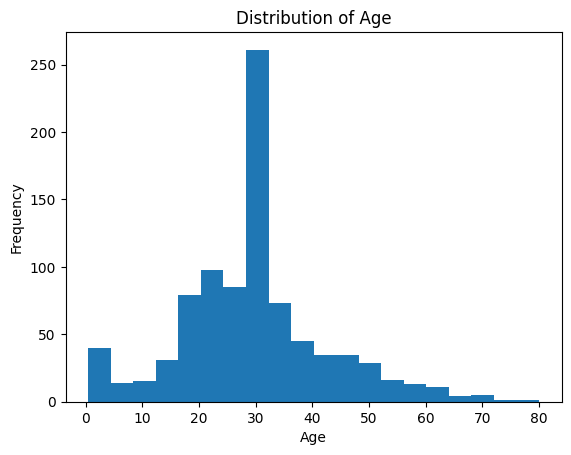

In [ ]:

#AGE DISTRIBUTION
plt.figure()
plt.hist(df['Age'], bins=20)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

 # Age Distribution
Most passengers were between 20 and 40 years old.
The age distribution appears slightly right-skewed.

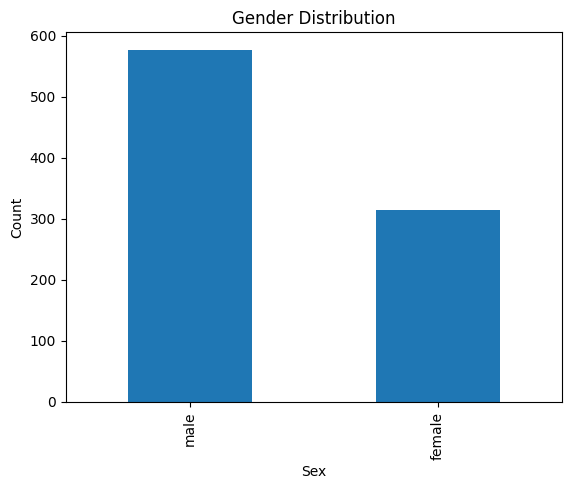

In [13]:
#GENDER DISTRIBUTION
plt.figure()
df['Sex'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

# Gender Distribution
There were significantly more male passengers than female passengers on the Titanic.

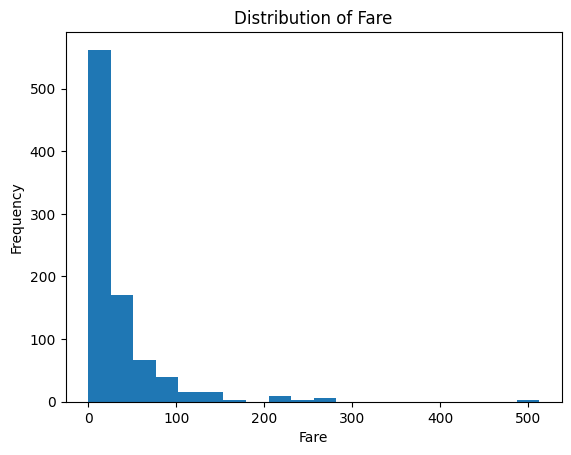

In [14]:
#FARE DISTRIBUTION
plt.figure()
plt.hist(df['Fare'], bins=20)
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

# Fare Distribution
Most passengers paid lower ticket fares, while a small number paid very high fares.
The distribution is highly right-skewed.

BIVARIATE ANALYSIS


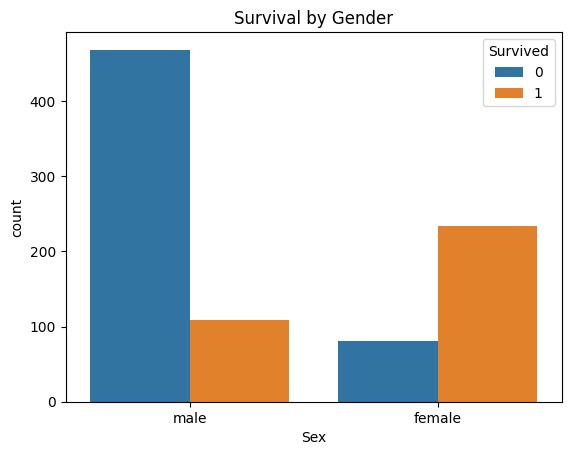

In [ ]:

#Survival by Gender
plt.figure()
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

# Survival By Gender
Female passengers had a much higher survival rate compared to male passengers.
This suggests that gender played a major role in survival.

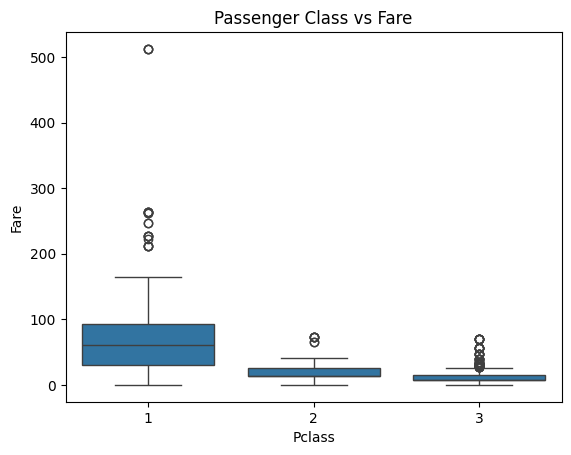

In [16]:
#Pclass vs Fare
plt.figure()
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title("Passenger Class vs Fare")
plt.show()

# Pclass VS Fare
First-class passengers paid significantly higher fares compared to second and third-class passengers.

PHASE 4: THE BIG PICTURE( MULTIVARIATE & STORYTELLING)

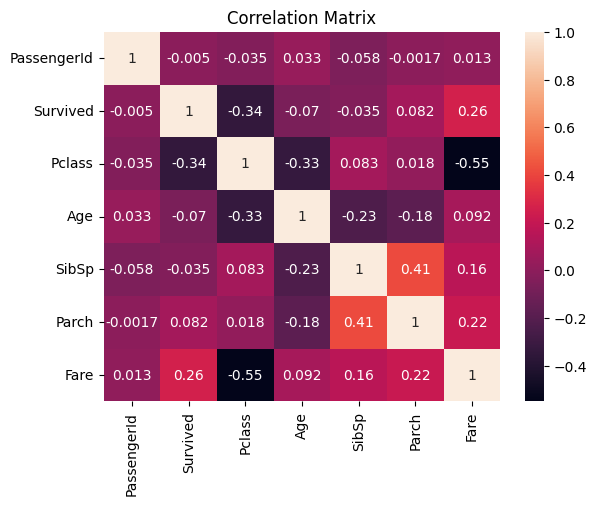

In [ ]:

#Correlation Matrix
plt.figure()
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

# correlation Matrix
Fare and Pclass show a strong negative correlation, meaning higher-class passengers paid higher fares.
Survived has positive correlation with Fare and negative correlation with Pclass.
Age has weak correlation with most variables.

# Executive Summary

1. Passenger class strongly influenced survival rates, with first-class passengers more likely to survive.
2. Gender played a crucial role, as female passengers had significantly higher survival rates.
3. Higher ticket fare was associated with better survival chances, indicating socioeconomic influence.

Overall, the analysis reveals that social class and gender were the most important factors affecting survival on the Titanic.

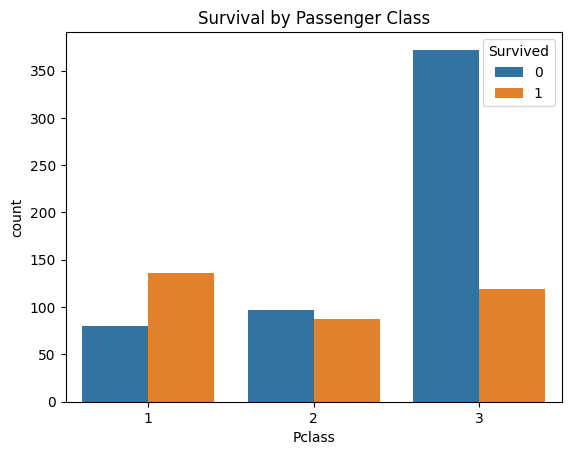

In [18]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()